### *This jupyter notebook will give an insight of the basic model manipulations.*

add the metabolite summary
add FVA alysis

setting up environment

In [ ]:
%pip install cobra

In [2]:
import cobra
import pandas as pd
from cobra.io import load_model
from cobra.io import load_json_model, save_json_model, load_matlab_model, save_matlab_model, read_sbml_model, write_sbml_model
from cobra import Model, Reaction, Metabolite, Gene
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

read model

In [5]:
model = read_sbml_model('GAM_NGAM_update.sbml')

model fluxes summary

In [6]:
model.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
ca2_e,EX_ca2_e,0.000241,0,0.00%
cl_e,EX_cl_e,0.000241,0,0.00%
co2_e,EX_co2_e,2.35,1,100.00%
cobalt2_e,EX_cobalt2_e,4.63E-06,0,0.00%
cu2_e,EX_cu2_e,3.283E-05,0,0.00%
fe2_e,EX_fe2_e,0.0007034,0,0.00%
h2_e,EX_h2_e,18.78,0,0.00%
k_e,EX_k_e,0.009038,0,0.00%
mg2_e,EX_mg2_e,0.0004017,0,0.00%
mn2_e,EX_mn2_e,3.2E-05,0,0.00%


set reaction constraints

In [ ]:
model.reactions.get_by_id('HYD1pp').bounds = -0.0, 0.0

set exchange reactions bounds

In [ ]:
# set reactions bounds for a specific reaction 
reaction = model.reactions.get_by_id('EX_h2_e')
reaction.bounds = -19.48, 0.0

reaction = model.reactions.get_by_id('EX_o2_e')
reaction.bounds = -6.92, 0.0

reaction = model.reactions.get_by_id('EX_ac_e')
reaction.bounds = -2.50, 0.0

check reaction information

In [7]:
reaction_id_to_check = 'HYD1pp'
reaction = model.reactions.get_by_id(reaction_id_to_check)
print(f"Reaction ID: {reaction.id}")
print(f"Name: {reaction.name}")
print(f"Equation: {reaction.reaction}")
print(f"Lower Bound: {reaction.lower_bound}")
print(f"Upper Bound: {reaction.upper_bound}")
sum = 0
#reaction.name = '(S)-2-Acetolactate pyruvate-lyase (carboxylating)'
print("\nMetabolites and Stoichiometry:")
for metabolite, coefficient in reaction.metabolites.items():
    print(f"{metabolite.id:<15}: {coefficient:>25}  Name: {metabolite.name:<60}  Charge: {metabolite.charge:>3}  Formula: {metabolite.formula}")
    sum += coefficient * metabolite.charge
print(f'\nSum charge: {sum}')
print("\nAssociated Genes:")
for gene in reaction.genes:
    print(gene.id)

Reaction ID: HYD1pp
Name: Hydrogenase (ubiquinone-8: 2 protons) (periplasm)
Equation: h2_c + 2.0 h_c + q8_c --> 2.0 h_p + q8h2_c
Lower Bound: 0.0
Upper Bound: 1000.0

Metabolites and Stoichiometry:
h2_c           :                      -1.0  Name: Hydrogen                                                      Charge:   0  Formula: H2
h_c            :                      -2.0  Name: H+                                                            Charge:   1  Formula: H
q8_c           :                      -1.0  Name: Ubiquinone-8                                                  Charge:   0  Formula: C49H74O4
h_p            :                       2.0  Name: H+                                                            Charge:   1  Formula: H
q8h2_c         :                       1.0  Name: Ubiquinol-8                                                   Charge:   0  Formula: C49H76O4

Sum charge: 0.0

Associated Genes:
AAFOLC_02510
AAFOLC_02515
AAFOLC_02505


create a dataframe with significant reaction fluxes

In [8]:
solution = model.optimize()
significant_reactions = [
    [
        model.reactions[RctIdx].name, 
        solution.to_frame().iloc[RctIdx].name, 
        model.reactions[RctIdx].reaction, 
        round(solution.fluxes[RctIdx], 2)
    ]
    for RctIdx in np.where(np.abs(solution.fluxes) > 3)[0]
]

# Create a DataFrame for better visualization
df = pd.DataFrame(significant_reactions, columns=["Reaction Name", "Reaction ID", "Reaction Equation", "Flux"])

# Print the DataFrame
df

C:\Users\adam-1y9pxi6q95ggpmx\AppData\Local\Temp\ipykernel_7072\4250613037.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  round(solution.fluxes[RctIdx], 2)


,Reaction Name,Reaction ID,Reaction Equation,Flux
0,EX_h2_e,EX_h2_e,h2_e <--,-18.78
1,EX_h2o_e,EX_h2o_e,h2o_e <=>,17.54
2,EX_o2_e,EX_o2_e,o2_e <--,-6.92
3,ATP synthase (four protons for one ATP) (perip...,ATPS4rpp,adp_c + 4.0 h_p + pi_c <=> atp_c + h2o_c + 3.0...,20.78
4,Cytochrome oxidase bd (ubiquinol-8: 2 protons)...,CYTBDpp,2.0 h_c + 0.5 o2_c + q8h2_c --> h2o_c + 2.0 h_...,13.85
5,Glyceraldehyde-3-phosphate dehydrogenase,GAPD,g3p_c + nad_c + pi_c <=> 13dpg_c + h_c + nadh_c,-3.72
6,Bidirectional [NiFe] Hydrogenase,H2ASE_syn,h_c + nadph_c <=> h2_c + nadp_c,-18.78
7,H2O transport via diffusion,H2Ot,h2o_e <=> h2o_c,-17.54
8,Hydrogen transport via diffusion (extracellula...,H2tex,h2_e <=> h2_p,18.78
9,Hydrogen transport diffusion (periplasm),H2tpp,h2_p <=> h2_c,18.78


## plotting

open experimental growth data

In [9]:
#file_path ='C:\\Users\\adam-1y9pxi6q95ggpmx\\Documents\\PhD\\10-19 Research\\11 Data\\11.03 Fluxes values\\plot_data - Copy.xlsx'
file_path ='C:\\Users\\adam-1y9pxi6q95ggpmx\\Documents\\PhD\\10-19 Research\\11 Data\\11.03 Fluxes values\\240823_growth_data.xlsx'
excel_data = pd.read_excel(file_path)
#excel_data = excel_data.drop([0,16])
excel_data

,Unnamed: 0,dilRate,H2 Flux theoretic,O2 flux theoretic,CO2 flux theoretic
0,0,0.046160,19.489454,6.926103,2.509541
1,1,0.035260,17.380479,6.315240,2.058461
2,2,0.026357,15.628204,5.897692,1.617025
3,3,0.020724,15.387005,6.040324,1.431369
4,4,0.021499,18.837676,7.716395,1.664021
5,5,0.018587,17.710821,7.343595,1.465021


simulate the growth with different growth constraint

In [10]:

#addition of a growth rate column
excel_data['growth_rate'] = None
for index, row in excel_data.iterrows():
    
    # Set bounds for H2 flux
    h2_reaction = model.reactions.get_by_id('EX_h2_e')
    h2_reaction.bounds = (-row['H2 Flux theoretic'], 0.0)

    # Set bounds for O2 flux
    o2_reaction = model.reactions.get_by_id('EX_o2_e')
    o2_reaction.bounds = (-100, 0.0)

    # Set bounds for CO2 flux
    co2_reaction = model.reactions.get_by_id('EX_co2_e')
    co2_reaction.bounds = (-row['CO2 flux theoretic'], 0.0)

    # Optimize the model
    solution = model.slim_optimize()
    print(solution)
    print(model.reactions.get_by_id('EX_h2_e').flux)
    print(model.reactions.get_by_id('EX_o2_e').flux)
    print(model.reactions.get_by_id('EX_co2_e').flux)


    # Update the DataFrame with the solution
    excel_data.at[index, 'growth_rate'] = solution

    # Assuming `solution` is an object that has a `fluxes` attribute
    excel_data.at[index, 'H2 Flux model'] = model.reactions.get_by_id('EX_h2_e').flux
    excel_data.at[index, 'O2 Flux model'] = model.reactions.get_by_id('EX_o2_e').flux
    excel_data.at[index, 'CO2 Flux model'] = model.reactions.get_by_id('EX_co2_e').flux

0.04895696686399554
-19.48945397637468
-7.131714846266245
-2.4846510642993964
0.040559428048940006
-17.38047889767114
-6.5254346263537855
-2.05846139016624
0.03186146558649834
-15.62820409507131
-6.113539251882725
-1.617024694351714
0.02820334627815979
-15.38700510339855
-6.188186945191853
-1.431368788460968
0.032787464403364615
-18.83767618518079
-7.668851357774772
-1.664020741967543
0.028866426717566916
-17.71082089634215
-7.31470381664255
-1.465021271958692


plot simulated data against experimental data

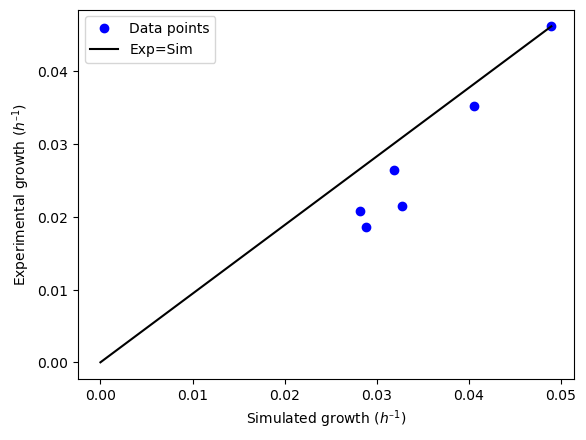

In [12]:
experimental_growth = excel_data['dilRate']
simulated_growth = excel_data['growth_rate']

# Plotting the data
plt.plot(simulated_growth, experimental_growth, 'o', color='blue', label='Data points')

plt.plot([0, max(simulated_growth)], [0, max(experimental_growth)], 'k-', label='Exp=Sim')

# Labels and legend
plt.xlabel('Simulated growth ($h^{–1}$)')
plt.ylabel('Experimental growth ($h^{–1}$)')
plt.legend()

# Save the plot
plt.savefig('Plotting simulation and measured growth.png')

# Display the plot
plt.show()

create a dataframe of different h2 uptake rate depending of co2 uptake rate

In [17]:
# Define the empty DataFrame for growth data
growth_data = {'growth_rate': [], 'H2 Flux model': [], 'O2 Flux model': [], 'CO2 Flux model': []}
sim_growth_df = pd.DataFrame(growth_data)
rows_list = []

# Set bounds for O2 flux
o2_reaction = model.reactions.get_by_id('EX_o2_e')
o2_reaction.bounds = (-100, 0.0)

# Set bounds for CO2 flux
co2_reaction = model.reactions.get_by_id('EX_co2_e')
co2_reaction.bounds = (-100, 0.0)

# Use np.arange to create a range with a step size of 0.5
for h2_flux in np.arange(5, 21, 0.5):  # Start at 14, end at 21, with step size of 0.5
    
    # Set bounds for H2 flux
    h2_reaction = model.reactions.get_by_id('EX_h2_e')
    h2_reaction.bounds = (-h2_flux, 0.0)

    # Optimize the model
    solution = model.slim_optimize()

    row = {
        'growth_rate': solution,
        'H2 Flux model': model.reactions.get_by_id('EX_h2_e').flux,
        'O2 Flux model': model.reactions.get_by_id('EX_o2_e').flux,
        'CO2 Flux model': model.reactions.get_by_id('EX_co2_e').flux
    }
    rows_list.append(row)

# Convert the list of rows into a DataFrame
sim_growth_df = pd.DataFrame(rows_list)

c:\Users\adam-1y9pxi6q95ggpmx\AppData\Local\anaconda3\Lib\site-packages\cobra\util\solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


plot it

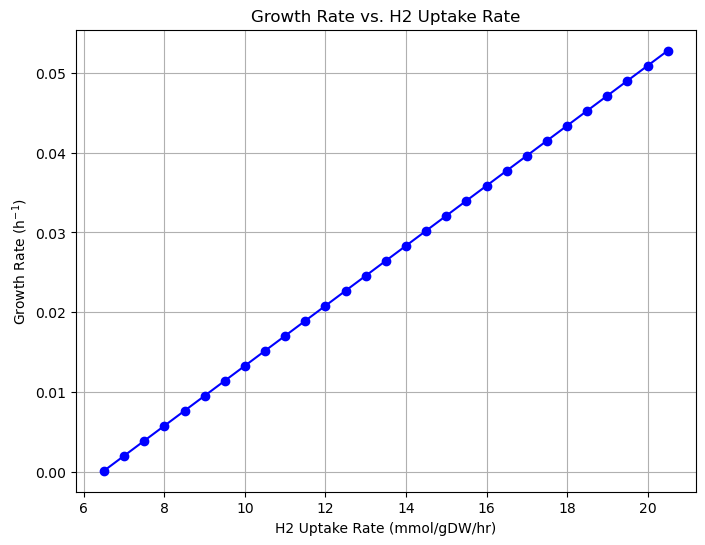

In [18]:
import matplotlib.pyplot as plt

# Plotting growth rate vs. H2 uptake rate
plt.figure(figsize=(8, 6))
plt.plot(-sim_growth_df['H2 Flux model'], sim_growth_df['growth_rate'], marker='o', linestyle='-', color='blue')

# Adding labels and title
plt.xlabel('H2 Uptake Rate (mmol/gDW/hr)')
plt.ylabel('Growth Rate (h$^{-1}$)')
plt.title('Growth Rate vs. H2 Uptake Rate')

# Show grid
plt.grid(True)

# Save the figure (optional)
plt.savefig('growth_rate_vs_h2_uptake_rate.png')

# Show the plot
plt.show()